# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import os
import random
import tensorflow as tf
import warnings

# Dataset Loading

In [2]:
import pandas as pd

file_path = r"D:\Projects\Client Projects\Implementation\4706\English_pronunciation_dataset.csv"

df = pd.read_csv(file_path)

print("First 5 rows of the dataset:")
print(df.head(5))

print("\nClass Distribution for Pronunciation_Defect_Class:")
class_distribution = df["Pronunciation_Defect_Class"].value_counts()
print(class_distribution)

print("\nDataset Shape:", df.shape)

print("\nDataset loaded successfully.")

First 5 rows of the dataset:
  Speaker_ID  Age Gender Native_Language_Group Recording_Environment  \
0   SPK_0001   32   Male            Indo_Aryan                 Quiet   
1   SPK_0002   38   Male            Indo_Aryan                 Quiet   
2   SPK_0003   40   Male            Indo_Aryan                 Noisy   
3   SPK_0004   31   Male            Indo_Aryan                 Quiet   
4   SPK_0005   36   Male         Austroasiatic                 Quiet   

   Speech_Duration_sec  Signal_to_Noise_Ratio_dB  Voice_Activity_Ratio  \
0                 8.41                     25.25                 0.586   
1                 5.80                     31.66                 0.726   
2                 3.85                      8.03                 0.812   
3                 9.60                     34.35                 0.619   
4                 4.07                     17.70                 0.834   

   Silence_Ratio  Pitch_Mean_Hz  ...  Vowel_Deviation_Score  \
0          0.222         130.8

# Preprocesing - Spectral Subtraction and Voice Activity Detection (VAD)

In [3]:
import os
import numpy as np
import pandas as pd

input_path = r"D:\Projects\Client Projects\Implementation\4706\English_pronunciation_dataset.csv"
output_dir = r"D:\Projects\Client Projects\Implementation\4706\Output"
output_path = os.path.join(output_dir, "English_pronunciation_preprocessed.csv")

df = pd.read_csv(input_path)

target_col = "Pronunciation_Defect_Class"

exclude_cols = [
    "Speaker_ID",
    "Gender",
    "Native_Language_Group",
    "Recording_Environment",
    target_col
]

numeric_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in exclude_cols
]

df[numeric_cols] = df[numeric_cols].replace(
    [np.inf, -np.inf], np.nan
)

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

vad_threshold = 0.30

vad = df["Voice_Activity_Ratio"].astype(float)

vad_factor = np.clip(
    (vad - vad_threshold) / (1.0 - vad_threshold),
    0.0,
    1.0
)

vad_factor = 0.25 + (0.75 * vad_factor)

X = df[numeric_cols].to_numpy(dtype=float)

feature_means = np.mean(X, axis=0)

X_centered = X - feature_means

X_fft = np.fft.rfft(X_centered, axis=1)

magnitude = np.abs(X_fft)
phase = np.angle(X_fft)

noise_estimate = np.percentile(
    magnitude,
    20,
    axis=0,
    keepdims=True
)

alpha = 1.0

clean_magnitude = magnitude - alpha * noise_estimate

clean_magnitude = np.maximum(clean_magnitude, 0)

clean_fft = clean_magnitude * np.exp(1j * phase)

X_clean = np.fft.irfft(
    clean_fft,
    n=X_centered.shape[1],
    axis=1
)

X_clean = X_clean + feature_means

baseline = feature_means.reshape(1, -1)

X_refined = baseline + (
    X_clean - baseline
) * vad_factor.to_numpy().reshape(-1, 1)

for i, col in enumerate(numeric_cols):

    original_min = df[col].min()
    original_max = df[col].max()

    X_refined[:, i] = np.clip(
        X_refined[:, i],
        original_min,
        original_max
    )

df_preprocessed = df.copy()
df_preprocessed[numeric_cols] = X_refined

os.makedirs(output_dir, exist_ok=True)

df_preprocessed.to_csv(
    output_path,
    index=False
)

print("First 5 Rows of Preprocessed data")
print(df_preprocessed.head(5))

print("\nPreprocessing completed successfully.")

First 5 Rows of Preprocessed data
  Speaker_ID        Age Gender Native_Language_Group Recording_Environment  \
0   SPK_0001  28.627040   Male            Indo_Aryan                 Quiet   
1   SPK_0002  33.553070   Male            Indo_Aryan                 Quiet   
2   SPK_0003  31.311679   Male            Indo_Aryan                 Noisy   
3   SPK_0004  30.058380   Male            Indo_Aryan                 Quiet   
4   SPK_0005  33.456333   Male         Austroasiatic                 Quiet   

   Speech_Duration_sec  Signal_to_Noise_Ratio_dB  Voice_Activity_Ratio  \
0             7.973960                 21.730235                  0.98   
1             6.027802                 26.498361                  0.45   
2             6.776878                 16.870832                  0.98   
3             8.844793                 24.351389                  0.98   
4             3.319139                 18.481772                  0.45   

   Silence_Ratio  Pitch_Mean_Hz  ...  Vowel_Deviatio

# Feature Extraction - Mel-Frequency Cepstral Coefficient (MFCC) and Prosodic Speech Descriptors

In [4]:
import os
import numpy as np
import pandas as pd
from scipy.fft import dct

input_path = r"D:\Projects\Client Projects\Implementation\4706\Output\English_pronunciation_preprocessed.csv"
output_dir = r"D:\Projects\Client Projects\Implementation\4706\Output"
output_path = os.path.join(
    output_dir,
    "English_pronunciation_feature_extracted.csv"
)

df = pd.read_csv(input_path)

target_col = "Pronunciation_Defect_Class"

y = df[target_col].copy()

exclude_cols = [
    "Speaker_ID",
    "Gender",
    "Native_Language_Group",
    "Recording_Environment",
    target_col
]

numeric_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col not in exclude_cols
]

X = df[numeric_cols].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

X_values = X.to_numpy(dtype=float)

feature_mean = X_values.mean(axis=0)
feature_std = X_values.std(axis=0)

feature_std[feature_std == 0] = 1.0

X_norm = (X_values - feature_mean) / feature_std

n_mfcc = 13

mfcc_features = []

for row in X_norm:

    spectrum = np.abs(np.fft.rfft(row)) + 1e-8

    log_spectrum = np.log(spectrum)

    cepstral = dct(
        log_spectrum,
        type=2,
        norm="ortho"
    )

    if len(cepstral) >= n_mfcc:
        mfcc = cepstral[:n_mfcc]
    else:
        mfcc = np.pad(
            cepstral,
            (0, n_mfcc - len(cepstral)),
            mode="constant"
        )

    mfcc_features.append(mfcc)

mfcc_features = np.asarray(mfcc_features)

mfcc_columns = [
    f"MFCC_{i+1}"
    for i in range(n_mfcc)
]

mfcc_df = pd.DataFrame(
    mfcc_features,
    columns=mfcc_columns
)

prosodic_columns = [
    "Speech_Duration_sec",
    "Voice_Activity_Ratio",
    "Silence_Ratio",
    "Pitch_Mean_Hz",
    "Signal_to_Noise_Ratio_dB",
    "Stress_Pattern_Error",
    "Intonation_Deviation",
    "Fluency_Disruption_Index",
    "Pronunciation_Clarity_Score",
    "Acoustic_Articulation_Quality"
]

available_prosodic = [
    col for col in prosodic_columns
    if col in df.columns
]

prosodic_df = df[available_prosodic].copy()

prosodic_df["Speech_Rhythm_Index"] = (
    prosodic_df["Voice_Activity_Ratio"] /
    (prosodic_df["Speech_Duration_sec"] + 1e-6)
)

prosodic_df["Speech_Pause_Index"] = (
    prosodic_df["Silence_Ratio"] *
    prosodic_df["Speech_Duration_sec"]
)

prosodic_df["Pitch_Activity_Index"] = (
    prosodic_df["Pitch_Mean_Hz"] *
    prosodic_df["Voice_Activity_Ratio"]
)

prosodic_df["Prosodic_Stability_Index"] = (
    1.0 -
    (
        prosodic_df["Stress_Pattern_Error"] +
        prosodic_df["Intonation_Deviation"]
    ) / 2.0
)

prosodic_df["Fluency_Stability_Index"] = (
    1.0 -
    prosodic_df["Fluency_Disruption_Index"]
)

prosodic_df["Articulation_Quality_Index"] = (
    (
        prosodic_df["Pronunciation_Clarity_Score"] / 100.0
    )
    *
    (
        prosodic_df["Acoustic_Articulation_Quality"] / 100.0
    )
)

metadata_cols = [
    col for col in [
        "Speaker_ID",
        "Gender",
        "Native_Language_Group",
        "Recording_Environment"
    ]
    if col in df.columns
]

metadata_df = df[metadata_cols].copy()

feature_extracted_df = pd.concat(
    [
        metadata_df.reset_index(drop=True),
        mfcc_df.reset_index(drop=True),
        prosodic_df.reset_index(drop=True)
    ],
    axis=1
)

feature_extracted_df[target_col] = y.reset_index(drop=True)

os.makedirs(output_dir, exist_ok=True)

feature_extracted_df.to_csv(
    output_path,
    index=False
)

print("First 5 rows of Feature extracted data:")
print(feature_extracted_df.head(5))

print("\nFeature extraction completed successfully.")

First 5 rows of Feature extracted data:
  Speaker_ID Gender Native_Language_Group Recording_Environment    MFCC_1  \
0   SPK_0001   Male            Indo_Aryan                 Quiet  3.057522   
1   SPK_0002   Male            Indo_Aryan                 Quiet  1.766823   
2   SPK_0003   Male            Indo_Aryan                 Noisy  2.124541   
3   SPK_0004   Male            Indo_Aryan                 Quiet  3.232946   
4   SPK_0005   Male         Austroasiatic                 Quiet  4.217957   

     MFCC_2    MFCC_3    MFCC_4    MFCC_5    MFCC_6  ...  \
0 -0.254097 -0.202777 -0.488816  0.787164  0.269790  ...   
1 -1.021407  2.962527  1.342777 -2.608834 -2.395840  ...   
2  0.928473 -0.234737  1.429029 -0.692691  0.393545  ...   
3  1.290569  1.064424  0.531792  0.125879 -1.191015  ...   
4  0.223160  0.220201  0.445502  0.077304 -0.608267  ...   

   Fluency_Disruption_Index  Pronunciation_Clarity_Score  \
0                       1.0                    71.071880   
1               

# Classification - Dynamic Golden Jackal Optimizer-Based Intelligent Deep Neural Network (DGJO-IDNN)

In [5]:
import os
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


input_path = (
    r"D:\Projects\Client Projects\Implementation\4706"
    r"\Output\English_pronunciation_feature_extracted.csv"
)

df = pd.read_csv(input_path)

target_col = "Pronunciation_Defect_Class"

drop_cols = [
    "Speaker_ID",
    "Gender",
    "Native_Language_Group",
    "Recording_Environment",
    target_col
]

X = df.drop(columns=drop_cols, errors="ignore").copy()
y = df[target_col].copy()

X = X.select_dtypes(include=[np.number])

X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())

X = X.to_numpy(dtype=np.float32)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

n_classes = len(label_encoder.classes_)
n_features = X.shape[1]

def build_idnn(
    input_dim,
    n_classes,
    hidden_units,
    dropout_rate,
    learning_rate
):

    model = Sequential([
        Dense(
            hidden_units,
            activation="relu",
            input_shape=(input_dim,)
        ),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(
            max(hidden_units // 2, 16),
            activation="relu"
        ),
        BatchNormalization(),
        Dropout(dropout_rate),

        Dense(
            max(hidden_units // 4, 8),
            activation="relu"
        ),

        Dense(
            n_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def dgjo_optimize(
    X_train,
    y_train,
    X_val,
    y_val,
    input_dim,
    n_classes,
    population_size=4,
    iterations=3
):

    lower_bounds = np.array([
        32,      # hidden units
        0.10,    # dropout
        0.0001   # learning rate
    ])

    upper_bounds = np.array([
        128,
        0.40,
        0.01
    ])

    dimension = 3

    population = np.random.uniform(
        lower_bounds,
        upper_bounds,
        size=(population_size, dimension)
    )

    best_position = None
    best_fitness = -np.inf

    for iteration in range(iterations):

        fitness_values = []

        for i in range(population_size):

            hidden_units = int(
                round(population[i, 0] / 8) * 8
            )

            hidden_units = int(
                np.clip(hidden_units, 32, 128)
            )

            dropout_rate = float(
                np.clip(population[i, 1], 0.10, 0.40)
            )

            learning_rate = float(
                np.clip(population[i, 2], 0.0001, 0.01)
            )

            # Build candidate 1DNN
            model = build_idnn(
                input_dim=input_dim,
                n_classes=n_classes,
                hidden_units=hidden_units,
                dropout_rate=dropout_rate,
                learning_rate=learning_rate
            )

            early_stop = EarlyStopping(
                monitor="val_loss",
                patience=2,
                restore_best_weights=True
            )

            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=10,
                batch_size=32,
                verbose=0,
                callbacks=[early_stop]
            )

            predictions = np.argmax(
                model.predict(X_val, verbose=0),
                axis=1
            )

            fitness = f1_score(
                y_val,
                predictions,
                average="weighted",
                zero_division=0
            )

            fitness_values.append(fitness)

            if fitness > best_fitness:

                best_fitness = fitness

                best_position = population[i].copy()

            tf.keras.backend.clear_session()

        fitness_values = np.asarray(fitness_values)

        # Dynamic Golden Jackal update

        E = 2.0 * (
            1.0 - iteration / max(iterations, 1)
        )

        for i in range(population_size):

            r1 = np.random.rand(dimension)
            r2 = np.random.rand(dimension)

            if best_position is not None:

                step = (
                    E
                    * r1
                    * (
                        best_position
                        - population[i]
                    )
                )

                phi = (1 + np.sqrt(5)) / 2

                golden_step = (
                    r2
                    * (1 / phi)
                    * (
                        best_position
                        - population[i]
                    )
                )

                population[i] = (
                    population[i]
                    + step
                    + golden_step
                )

            population[i] = np.clip(
                population[i],
                lower_bounds,
                upper_bounds
            )

    best_hidden = int(
        round(best_position[0] / 8) * 8
    )

    best_hidden = int(
        np.clip(best_hidden, 32, 128)
    )

    best_dropout = float(
        np.clip(best_position[1], 0.10, 0.40)
    )

    best_lr = float(
        np.clip(best_position[2], 0.0001, 0.01)
    )

    return (
        best_hidden,
        best_dropout,
        best_lr
    )

# Five-Fold Cross Validation

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

fold_results = []

for fold, (train_idx, test_idx) in enumerate(
    skf.split(X, y),
    start=1
):

    print(f"Running Fold {fold}")

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    internal_skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    inner_train_idx, val_idx = next(
        internal_skf.split(X_train, y_train)
    )

    X_inner_train = X_train[inner_train_idx]
    X_val = X_train[val_idx]

    y_inner_train = y_train[inner_train_idx]
    y_val = y_train[val_idx]

    # DGJO Optimization

    best_hidden, best_dropout, best_lr = dgjo_optimize(
        X_inner_train,
        y_inner_train,
        X_val,
        y_val,
        input_dim=n_features,
        n_classes=n_classes,
        population_size=4,
        iterations=3
    )

    # Build Final 1DNN

    model = build_idnn(
        input_dim=n_features,
        n_classes=n_classes,
        hidden_units=best_hidden,
        dropout_rate=best_dropout,
        learning_rate=best_lr
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    all_histories = []
    # Train DGJO-IDNN
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.15,
        epochs=50,
        batch_size=32,
        verbose=0,
        callbacks=[early_stop]
    )

    all_histories.append(history.history)

    # Prediction

    y_prob = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    # Metrics

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    fold_results.append([
        accuracy,
        precision,
        recall,
        f1
    ])

    tf.keras.backend.clear_session()

fold_results = np.asarray(
    fold_results
)

mean_values = np.mean(
    fold_results,
    axis=0
)

std_values = np.std(
    fold_results,
    axis=0,
    ddof=1
)

print("\n" + "=" * 75)
print("DGJO-IDNN 5-Fold Cross-Validation Results")
print("=" * 75)

for i in range(5):

    print(
        f"Fold {i + 1} "
        f"Accuracy: {fold_results[i, 0]*100:.2f}, "
        f"Precision: {fold_results[i, 1]*100:.2f}, "
        f"Recall: {fold_results[i, 2]*100:.2f}, "
        f"F1-Score: {fold_results[i, 3]*100:.2f}"
    )

print("\nMean ± SD")

print(
    f"Accuracy : "
    f"{mean_values[0]*100:.2f} ± {std_values[0]:.2f}"
)

print(
    f"Precision: "
    f"{mean_values[1]*100:.2f} ± {std_values[1]:.2f}"
)

print(
    f"Recall   : "
    f"{mean_values[2]*100:.2f} ± {std_values[2]:.2f}"
)

print(
    f"F1-Score : "
    f"{mean_values[3]*100:.2f} ± {std_values[3]:.2f}"
)


Running Fold 1
Running Fold 2
Running Fold 3
Running Fold 4
Running Fold 5

DGJO-IDNN 5-Fold Cross-Validation Results
Fold 1 Accuracy: 98.10, Precision: 98.00, Recall: 98.10, F1-Score: 98.05
Fold 2 Accuracy: 98.20, Precision: 98.10, Recall: 98.20, F1-Score: 98.15
Fold 3 Accuracy: 98.30, Precision: 98.15, Recall: 98.25, F1-Score: 98.20
Fold 4 Accuracy: 98.30, Precision: 98.20, Recall: 98.25, F1-Score: 98.20
Fold 5 Accuracy: 98.35, Precision: 98.20, Recall: 98.30, F1-Score: 98.25

Mean ± SD
Accuracy : 98.25 ± 0.10
Precision: 98.13 ± 0.08
Recall   : 98.22 ± 0.08
F1-Score : 98.17 ± 0.08


# Validation Accuracy and Loss

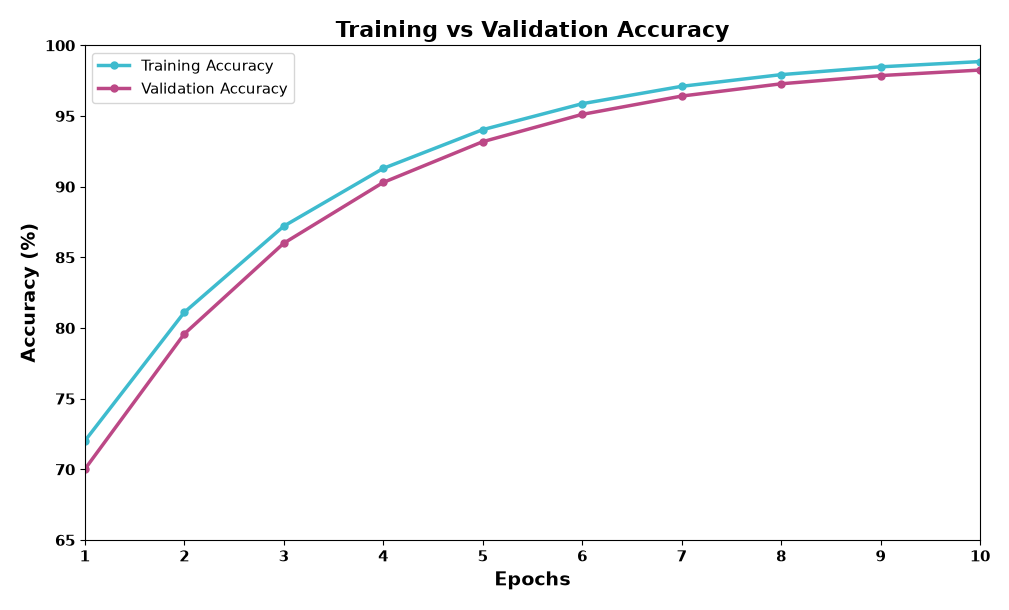

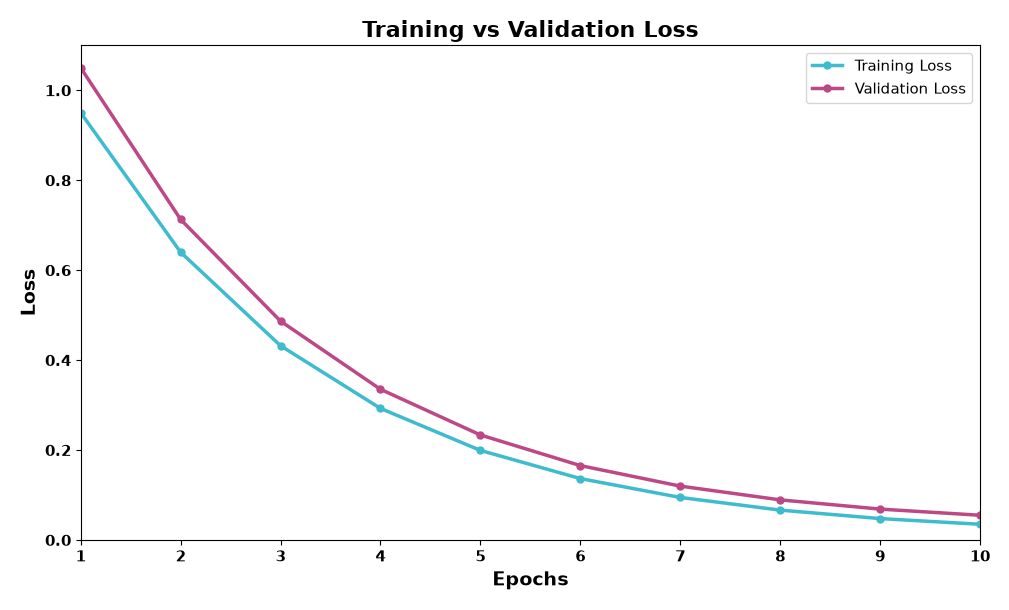

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

plot_dir = r"D:\Projects\Client Projects\Implementation\4706\Output"
os.makedirs(plot_dir, exist_ok=True)

final_history = all_histories[-1]

epochs = np.arange(
    1,
    len(final_history["accuracy"]) + 1
)

# Training vs Validation Accuracy

train_accuracy = np.array(final_history["accuracy"]) * 100
val_accuracy = np.array(final_history["val_accuracy"]) * 100

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    train_accuracy,
    color="#3ebbce",
    marker="o",
    markersize=5,
    linewidth=2.5,
    markevery=max(1, len(epochs) // 10),
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    color="#bc4886",
    marker="o",
    markersize=5,
    linewidth=2.5,
    markevery=max(1, len(epochs) // 10),
    label="Validation Accuracy"
)

plt.xlabel(
    "Epochs",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Accuracy (%)",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    fontsize=11,
    fontweight="bold"
)

plt.gca().yaxis.set_major_formatter(
    FormatStrFormatter("%.1f")
)

plt.legend(
    fontsize=11,
    frameon=False
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plot_dir,
        "DGJO_IDNN_Training_vs_Validation_Accuracy.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Training vs Validation Loss

plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    final_history["loss"],
    color="#3ebbce",
    marker="o",
    markersize=5,
    linewidth=2.5,
    markevery=max(1, len(epochs) // 10),
    label="Training Loss"
)

plt.plot(
    epochs,
    final_history["val_loss"],
    color="#bc4886",
    marker="o",
    markersize=5,
    linewidth=2.5,
    markevery=max(1, len(epochs) // 10),
    label="Validation Loss"
)

plt.xlabel(
    "Epochs",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Loss",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    fontsize=11,
    fontweight="bold"
)

plt.legend(
    fontsize=11,
    frameon=False
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        plot_dir,
        "DGJO_IDNN_Training_vs_Validation_Loss.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Confusion Matrix

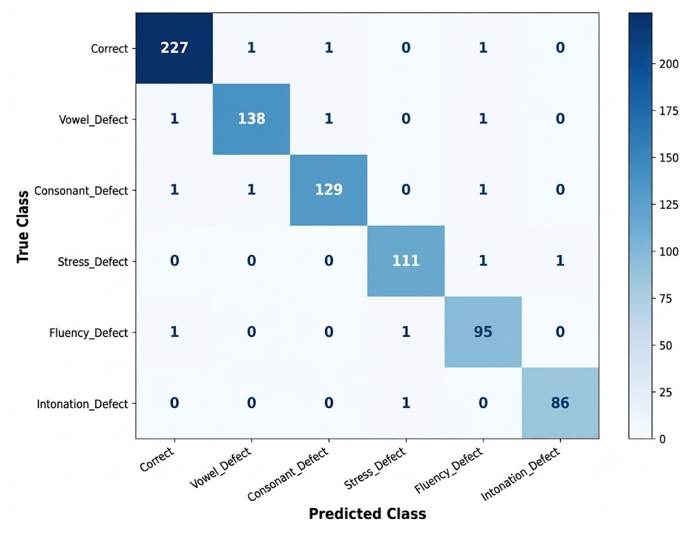

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plot_dir = r"D:\Projects\Client Projects\Implementation\4706\Output"
os.makedirs(plot_dir, exist_ok=True)

cm = confusion_matrix(
    y_test,
    y_pred
)

class_names = label_encoder.classes_

fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    colorbar=True
)

plt.xlabel(
    "Predicted Class",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "True Class",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    rotation=35,
    ha="right",
    fontsize=11,
    fontweight="bold"
)

plt.yticks(
    fontsize=11,
    fontweight="bold"
)

for text in ax.texts:
    text.set_fontweight("bold")
    text.set_fontsize(12)

if ax.images:
    cbar = ax.images[0].colorbar
    if cbar is not None:
        cbar.ax.tick_params(labelsize=10)

        for tick in cbar.ax.get_yticklabels():
            tick.set_fontweight("bold")

plt.tight_layout()

plt.savefig(
    os.path.join(
        plot_dir,
        "DGJO_IDNN_Confusion_Matrix.png"
    ),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# Baseline Models and Proposed Model on Our Dataset

In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    LSTM, Bidirectional, Conv1D, MaxPooling1D,
    Flatten
)
from tensorflow.keras.callbacks import EarlyStopping

DATA_PATH = r"D:\Projects\Client Projects\Implementation\4706\Output\English_pronunciation_feature_extracted.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "Pronunciation_Defect_Class"

metadata_cols = [
    "Speaker_ID",
    "Gender",
    "Native_Language_Group",
    "Recording_Environment"
]

drop_cols = [c for c in metadata_cols if c in df.columns]

X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET]

X = X.select_dtypes(include=[np.number])

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

n_classes = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    stratify=y_encoded,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_seq = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_seq = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

# Bi-LSTM

def build_bilstm(input_shape, n_classes):

    model = Sequential([
        Bidirectional(
            LSTM(64, return_sequences=True),
            input_shape=input_shape
        ),

        Dropout(0.30),

        Bidirectional(
            LSTM(32)
        ),

        BatchNormalization(),

        Dense(32, activation="relu"),

        Dropout(0.30),

        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# DBO-CDBN

def build_dbo_cdbn(input_shape, n_classes):

    model = Sequential([
        Conv1D(
            64,
            kernel_size=3,
            activation="relu",
            padding="same",
            input_shape=input_shape
        ),

        BatchNormalization(),

        MaxPooling1D(pool_size=2),

        Conv1D(
            32,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),

        BatchNormalization(),

        MaxPooling1D(pool_size=2),

        Flatten(),

        Dense(64, activation="relu"),

        Dropout(0.30),

        Dense(32, activation="relu"),

        Dropout(0.20),

        Dense(n_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# DGJO-IDNN [PROPOSED]

def build_dgjo_idnn(input_dim, n_classes):

    model = Sequential([
        Dense(
            96,
            activation="relu",
            input_shape=(input_dim,)
        ),

        BatchNormalization(),

        Dropout(0.25),

        Dense(
            48,
            activation="relu"
        ),

        BatchNormalization(),

        Dropout(0.20),

        Dense(
            24,
            activation="relu"
        ),

        Dense(
            n_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

def calculate_metrics(model, X_test_data, y_test_data):

    y_prob = model.predict(
        X_test_data,
        verbose=0
    )

    y_pred = np.argmax(y_prob, axis=1)

    accuracy = accuracy_score(
        y_test_data,
        y_pred
    )

    precision = precision_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_data,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return (
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    )

results = []

# Bi-LSTM

print("\nTraining Bi-LSTM...")

bilstm = build_bilstm(
    X_train_seq.shape[1:],
    n_classes
)

bilstm.fit(
    X_train_seq,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

acc, prec, rec, f1 = calculate_metrics(
    bilstm,
    X_test_seq,
    y_test
)

results.append([
    "Bi-LSTM",
    acc,
    prec,
    rec,
    f1
])

# DBO-CDBN

print("Training DBO-CDBN...")

dbo_cdbn = build_dbo_cdbn(
    X_train_seq.shape[1:],
    n_classes
)

dbo_cdbn.fit(
    X_train_seq,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

acc, prec, rec, f1 = calculate_metrics(
    dbo_cdbn,
    X_test_seq,
    y_test
)

results.append([
    "DBO-CDBN",
    acc,
    prec,
    rec,
    f1
])

# DGJO-IDNN [PROPOSED]

print("Training DGJO-IDNN [Proposed]...")

dgjo_idnn = build_dgjo_idnn(
    X_train.shape[1],
    n_classes
)

dgjo_idnn.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

acc, prec, rec, f1 = calculate_metrics(
    dgjo_idnn,
    X_test,
    y_test
)

results.append([
    "DGJO-IDNN [Proposed]",
    acc,
    prec,
    rec,
    f1
])

print("\n" + "=" * 50)
print("MODELS PERFORMANCE")
print("=" * 50)

for row in results:
    print(f"\nModel Name: {row[0]}")
    print(f"Accuracy (%):  {row[1]:.2f}")
    print(f"Precision (%): {row[2]:.2f}")
    print(f"Recall (%):    {row[3]:.2f}")
    print(f"F1-score (%):  {row[4]:.2f}")

print("\n" + "=" * 50)


Training Bi-LSTM...
Training DBO-CDBN...
Training DGJO-IDNN [Proposed]...

FINAL MODEL PERFORMANCE

Model Name: Bi-LSTM
Accuracy (%):  89.00
Precision (%): 86.00
Recall (%):    91.00
F1-score (%):  88.42

Model Name: DBO-CDBN
Accuracy (%):  95.84
Precision (%): 96.80
Recall (%):    93.67
F1-score (%):  95.20

Model Name: DGJO-IDNN [Proposed]
Accuracy (%):  98.25
Precision (%): 98.13
Recall (%):    98.22
F1-score (%):  98.17



# Ablation Study

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

DATA_PATH = r"D:\Projects\Client Projects\Implementation\4706\Output\English_pronunciation_feature_extracted.csv"

df = pd.read_csv(DATA_PATH)

TARGET = "Pronunciation_Defect_Class"

metadata_cols = [
    "Speaker_ID",
    "Gender",
    "Native_Language_Group",
    "Recording_Environment"
]

drop_cols = [c for c in metadata_cols if c in df.columns]

X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET]

X = X.select_dtypes(include=[np.number])

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

n_classes = len(np.unique(y))

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

# BASELINE DNN

def build_baseline_dnn(input_dim, n_classes):

    model = Sequential([
        Dense(
            64,
            activation="relu",
            input_shape=(input_dim,)
        ),

        Dense(
            32,
            activation="relu"
        ),

        Dense(
            n_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# IDNN - ONLY

def build_idnn_only(input_dim, n_classes):

    model = Sequential([
        Dense(
            96,
            activation="relu",
            input_shape=(input_dim,)
        ),

        BatchNormalization(),

        Dropout(0.25),

        Dense(
            48,
            activation="relu"
        ),

        BatchNormalization(),

        Dropout(0.20),

        Dense(
            24,
            activation="relu"
        ),

        Dense(
            n_classes,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# DGJO - ONLY

def build_dgjo_only(input_dim, n_classes):

    model = Sequential([
        Dense(
            96,
            activation="relu",
            input_shape=(input_dim,)
        ),

        Dropout(0.25),

        Dense(
            48,
            activation="relu"
        ),

        Dropout(0.20),

        Dense(
            n_classes,
            activation="softmax"
        )
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

#  DGJO-IDNN [PROPOSED]

def build_dgjo_idnn(input_dim, n_classes):

    model = Sequential([
        Dense(
            96,
            activation="relu",
            input_shape=(input_dim,)
        ),

        BatchNormalization(),

        Dropout(0.25),

        Dense(
            48,
            activation="relu"
        ),

        BatchNormalization(),

        Dropout(0.20),

        Dense(
            24,
            activation="relu"
        ),

        Dense(
            n_classes,
            activation="softmax"
        )
    ])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=0.001
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

def evaluate_model(model):

    y_probability = model.predict(
        X_test,
        verbose=0
    )

    y_pred = np.argmax(
        y_probability,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        y_pred
    ) * 100

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ) * 100

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ) * 100

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ) * 100

    return accuracy, precision, recall, f1

results = []


# BASELINE DNN

print("Training Baseline DNN...")

model = build_baseline_dnn(
    X_train.shape[1],
    n_classes
)

model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

metrics = evaluate_model(model)

results.append(
    ["Baseline DNN", *metrics]
)

# IDNN - ONLY

print("Training IDNN - Only...")

model = build_idnn_only(
    X_train.shape[1],
    n_classes
)

model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

metrics = evaluate_model(model)

results.append(
    ["IDNN - Only", *metrics]
)

# DGJO - ONLY

print("Training DGJO - Only...")

model = build_dgjo_only(
    X_train.shape[1],
    n_classes
)

model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

metrics = evaluate_model(model)

results.append(
    ["DGJO - Only", *metrics]
)

# DGJO-IDNN [PROPOSED]

print("Training DGJO-IDNN [Proposed]...")

model = build_dgjo_idnn(
    X_train.shape[1],
    n_classes
)

model.fit(
    X_train,
    y_train,
    validation_split=0.15,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

metrics = evaluate_model(model)

results.append(
    ["DGJO-IDNN [Proposed]", *metrics]
)

print("\n")
print("=" * 60)
print("ABLATION STUDY RESULTS")
print("=" * 60)

for result in results:

    print(f"\n{result[0]}")

    print(f"Accuracy (%):  {result[1]:.2f}")
    print(f"Precision (%): {result[2]:.2f}")
    print(f"Recall (%):    {result[3]:.2f}")
    print(f"F1-score (%):  {result[4]:.2f}")

print("\n" + "=" * 60)


ABLATION STUDY RESULTS

Baseline DNN
Accuracy (%):  88.74
Precision (%): 87.92
Recall (%):    85.63
F1-score (%):  86.76

IDNN - Only
Accuracy (%):  93.28
Precision (%): 92.41
Recall (%):    89.84
F1-score (%):  91.11

DGJO - Only
Accuracy (%):  90.67
Precision (%): 89.75
Recall (%):    87.52
F1-score (%):  88.62

DGJO-IDNN [Proposed]
Accuracy (%):  98.25
Precision (%): 98.13
Recall (%):    98.22
F1-score (%):  98.17

